In [1]:
!rm -rf dataset && mkdir -p dataset
!wget -O dataset/mnist.py https://raw.githubusercontent.com/WegraLee/deep-learning-from-scratch/master/dataset/mnist.py
!sed -i "s|url_base = 'http://yann.lecun.com/exdb/mnist/'|url_base = 'https://storage.googleapis.com/cvdf-datasets/mnist/'|g" dataset/mnist.py
!mkdir -p common && wget -O common/util.py https://raw.githubusercontent.com/WegraLee/deep-learning-from-scratch/master/common/util.py
import sys
import os
import numpy as np
sys.path.append(os.pardir)
from dataset.mnist import load_mnist
from common.util import im2col, col2im
from collections import OrderedDict


--2026-06-15 12:07:22--  https://raw.githubusercontent.com/WegraLee/deep-learning-from-scratch/master/dataset/mnist.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3655 (3.6K) [text/plain]
Saving to: ‘dataset/mnist.py’

dataset/mnist.py    100%[===================>]   3.57K  --.-KB/s    in 0s      

2026-06-15 12:07:22 (44.8 MB/s) - ‘dataset/mnist.py’ saved [3655/3655]

--2026-06-15 12:07:22--  https://raw.githubusercontent.com/WegraLee/deep-learning-from-scratch/master/common/util.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Len

In [2]:
np.random.seed(42)

In [3]:
normalize=True
flatten=False
one_hot_label=True
(x_train_full, t_train_full),(x_test,t_test) = load_mnist(
    normalize = True,
    flatten = False,
    one_hot_label = True
)

x_train_full.shape = (60000, 1, 28,28)
t_train_full.shape = (60000,10)


Done
Done
Done
Done
Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!


In [4]:
indices = np.arange(x_train_full.shape[0])
np.random.shuffle(indices)
x_train_full = x_train_full[indices]
t_train_full = t_train_full[indices]

# train : 5000, val: 1000
x_train = x_train_full[:5000]
t_train = t_train_full[:5000]

x_val = x_train_full[5000:6000]
t_val = t_train_full[5000:6000]

test_indices = np.random.choice(x_test.shape[0],1000,replace=False)
x_test = x_test[test_indices]
t_test = t_test[test_indices]


In [5]:
print("x_train shape      : ", x_train.shape)
print("t_train shape      : ", t_train.shape)
print("x_val shape        : ", x_val.shape)
print("t_val shape        : ", t_val.shape)
print("x_test_final shape : ", x_test.shape)
print("t_test_final shape : ", t_test.shape)

x_train shape      :  (5000, 1, 28, 28)
t_train shape      :  (5000, 10)
x_val shape        :  (1000, 1, 28, 28)
t_val shape        :  (1000, 10)
x_test_final shape :  (1000, 1, 28, 28)
t_test_final shape :  (1000, 10)


In [6]:
####### 변인 통제 #######

# input : (1,28,28)
# conv layer 1

FILTER_NUM = 30  ### 10 / 30 /50 ###
FILTER_SIZE = 5 ### 3*3  / 5*5 ###
STRIDE = 1
PAD = 0
ACT = "ReLU"
MAX_POOL = True ### True / False ###
POOL_SIZE = 2

HIDDEN_SIZE = 100
OUTPUT_SIZE = 10

OUTPUT_ACT= "Softmax"
LOSS = "crossentropyloss"
OPTIMIZER = "SGD"
LR=0.01
BATCH_SIZE=100
EPOCHS= 10 # or 20




In [7]:
class Convolution:
  def __init__(self, W, b, stride=STRIDE, pad=PAD):
    self.W = W
    self.b = b
    self.stride = stride
    self.pad = pad

    self.x = None
    self.col = None
    self.col_W = None

    self.dW = None
    self.db = None

  def forward(self, x):
    FN, C, FH, FW = self.W.shape
    N, C, H, W = x.shape
    out_h = 1 + int((H + 2*self.pad - FH) / self.stride)
    out_w = 1 + int((W + 2*self.pad - FW) / self.stride)
    col = im2col(x, FH, FW, self.stride, self.pad)
    col_W = self.W.reshape(FN, -1).T

    out = np.dot(col, col_W) + self.b
    out = out.reshape(N, out_h, out_w, -1).transpose(0, 3, 1, 2)
    self.x = x
    self.col = col
    self.col_W = col_W
    return out

  def backward(self, dout):
    FN, C, FH, FW = self.W.shape
    dout = dout.transpose(0,2,3,1).reshape(-1, FN)
    self.db = np.sum(dout, axis=0)
    self.dW = np.dot(self.col.T, dout)
    self.dW = self.dW.transpose(1, 0).reshape(FN, C, FH, FW)

    dcol = np.dot(dout, self.col_W.T)
    dx = col2im(dcol, self.x.shape, FH, FW, self.stride, self.pad)
    return dx

In [8]:
class Pooling:
  def __init__(self, pool_h, pool_w, stride=STRIDE, pad=PAD):
    self.pool_h = pool_h
    self.pool_w = pool_w
    self.stride = stride
    self.pad = pad
    self.x = None
    self.arg_max = None

  def forward(self, x):
    N, C, H, W = x.shape
    out_h = int(1 + (H - self.pool_h) / self.stride)
    out_w = int(1 + (W - self.pool_w) / self.stride)
    col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
    col = col.reshape(-1, self.pool_h*self.pool_w)
    arg_max = np.argmax(col, axis=1)
    out = np.max(col, axis=1)
    out = out.reshape(N, out_h, out_w, C).transpose(0, 3, 1, 2)
    self.x = x
    self.arg_max = arg_max
    return out


  def backward(self,dout):
    dout=dout.transpose(0,2,3,1)
    pool_size=self.pool_h*self.pool_w
    dmax=np.zeros((dout.size,pool_size))
    dmax[np.arange(self.arg_max.size),self.arg_max.flatten()]=dout.flatten()
    dmax=dmax.reshape(dout.shape+(pool_size,))

    dcol=dmax.reshape(dmax.shape[0]*dmax.shape[1]*dmax.shape[2],-1)
    dx=col2im(dcol,self.x.shape,self.pool_h,self.pool_w,self.stride,self.pad)

    return dx



In [9]:

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

def cross_entropy_error(y, t):
    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size

class Relu:
    def __init__(self):
        self.mask = None
    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy(); out[self.mask] = 0
        return out
    def backward(self, dout):
        dout[self.mask] = 0
        return dout

class Affine:
    def __init__(self, W, b):
        self.W, self.b = W, b
        self.x, self.dW, self.db = None, None, None
    def forward(self, x):
      self.original_x_shape = x.shape
      x = x.reshape(x.shape[0], -1)
      self.x = x
      return np.dot(self.x, self.W) + self.b

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)
        return dx.reshape(*self.original_x_shape)


class SoftmaxWithLoss:
    def __init__(self):
        self.loss, self.y, self.t = None, None, None
    def forward(self, x, t):
        self.t = t; self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)
        return self.loss
    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        return (self.y - self.t) / batch_size


class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]


In [10]:
class SimpleConvNet:
  def __init__(self, input_dim=(1, 28, 28),
    hidden_size=100,
    output_size=10,
    weight_init_std=0.1):
    filter_num = FILTER_NUM
    filter_size = FILTER_SIZE
    filter_pad = PAD
    filter_stride = STRIDE
    input_size = input_dim[1]
    conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
    if MAX_POOL :
      pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))
    else:
      pool_output_size = int(filter_num * conv_output_size * conv_output_size)

    # 가중치 초기화
    self.params = {}
    self.params["W1"] = weight_init_std * np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
    self.params['b1'] = np.zeros(filter_num)
    self.params['W2'] = weight_init_std * np.random.randn(pool_output_size, hidden_size)
    self.params['b2'] = np.zeros(hidden_size)
    self.params['W3'] = weight_init_std * \
    np.random.randn(hidden_size, output_size)
    self.params['b3'] = np.zeros(output_size)

    #계층 생성
    self.layers = OrderedDict()
    self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'],filter_stride, filter_pad)
    self.layers['Relu1'] = Relu()
    if MAX_POOL:
      self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
    else :
      pass
    self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2'])
    self.layers['Relu2'] = Relu()
    self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3'])
    self.last_layer = SoftmaxWithLoss()


  def predict(self,x):
    for layer in self.layers.values():
      x = layer.forward(x)
    return x

  #손실함수
  def loss (self,x,t):
    y=self.predict(x)
    return self.last_layer.forward(y,t)

  #기울기
  def gradient(self,x,t):
    self.loss(x,t)
    dout=1
    dout=self.last_layer.backward(dout)

    layers = list(self.layers.values())
    layers.reverse()
    for layer in layers:
      dout = layer.backward(dout)

    grads={}
    grads["W1"], grads["b1"] = self.layers["Conv1"].dW,self.layers["Conv1"].db
    grads["W2"], grads["b2"] = self.layers["Affine1"].dW, self.layers["Affine1"].db
    grads["W3"], grads["b3"] = self.layers["Affine2"].dW, self.layers["Affine2"].db

    return grads










In [11]:
train_losses = []
val_accuracies = []
train_accuracies = []

model= SimpleConvNet()
optimizer = SGD()
print(f"CNN : Filter size : {FILTER_SIZE}, Filter num : {FILTER_NUM}, POOLING : {MAX_POOL}")


for epoch in range(EPOCHS):
    # 데이터 셔플
    idx = np.random.permutation(x_train.shape[0])
    x_train_sh, t_train_sh = x_train[idx], t_train[idx]

    total_loss = 0
    train_acc_cnt = 0

    # --- [Train 루프] ---
    for i in range(0, x_train.shape[0], BATCH_SIZE):
        x_batch = x_train_sh[i:i+BATCH_SIZE]
        t_batch = t_train_sh[i:i+BATCH_SIZE]

        loss = model.loss(x_batch,t_batch)
        grads = model.gradient(x_batch, t_batch)


        # optimizer.step() 역할
        optimizer.update(model.params, grads)

        total_loss += loss * x_batch.shape[0]

        # 정확도 계산 (predicted == labels)
        y_pred = model.predict(x_batch)
        train_acc_cnt += np.sum(np.argmax(y_pred, axis=1) == np.argmax(t_batch, axis=1))

    avg_loss = total_loss / x_train.shape[0]
    train_losses.append(avg_loss)

    avg_train_acc = 100 * train_acc_cnt / x_train.shape[0]
    train_accuracies.append(avg_train_acc)

    # --- [Validation 루프] ---
    val_correct = 0
    for i in range(0, x_val.shape[0], BATCH_SIZE):
        x_v_batch = x_val[i:i+BATCH_SIZE]
        t_v_batch = t_val[i:i+BATCH_SIZE]

        y_val_pred = model.predict(x_v_batch)
        val_correct += np.sum(np.argmax(y_val_pred, axis=1) == np.argmax(t_v_batch, axis=1))

    val_acc = 100 * val_correct / x_val.shape[0]
    val_accuracies.append(val_acc)


    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f}, Train Acc: {avg_train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

CNN : Filter size : 5, Filter num : 30, POOLING : True
Epoch [1/10] Loss: 2.1113, Train Acc: 30.78%, Val Acc: 50.10%
Epoch [2/10] Loss: 1.4100, Train Acc: 64.18%, Val Acc: 71.80%
Epoch [3/10] Loss: 0.9152, Train Acc: 78.40%, Val Acc: 80.80%
Epoch [4/10] Loss: 0.6763, Train Acc: 83.28%, Val Acc: 84.30%
Epoch [5/10] Loss: 0.5591, Train Acc: 85.44%, Val Acc: 87.10%
Epoch [6/10] Loss: 0.4925, Train Acc: 87.12%, Val Acc: 87.90%
Epoch [7/10] Loss: 0.4478, Train Acc: 88.32%, Val Acc: 87.80%
Epoch [8/10] Loss: 0.4149, Train Acc: 89.06%, Val Acc: 88.30%
Epoch [9/10] Loss: 0.3914, Train Acc: 89.80%, Val Acc: 89.20%
Epoch [10/10] Loss: 0.3706, Train Acc: 90.28%, Val Acc: 89.30%


In [12]:
# 최종 평가
test_correct = 0

for i in range(0, x_test.shape[0], BATCH_SIZE):
    x_t_batch = x_test[i:i+BATCH_SIZE]
    t_t_batch = t_test[i:i+BATCH_SIZE]

    y_test_pred = model.predict(x_t_batch)

    test_correct += np.sum(np.argmax(y_test_pred, axis=1) == np.argmax(t_t_batch, axis=1))

final_test_acc = 100 * test_correct / x_test.shape[0]

print(f" CNN : Filter size : {FILTER_SIZE}, Filter num : {FILTER_NUM}, POOLING : {MAX_POOL}")
print(f" Test Accuracy: {final_test_acc:.2f}%")

 CNN : Filter size : 5, Filter num : 30, POOLING : True
 Test Accuracy: 89.80%


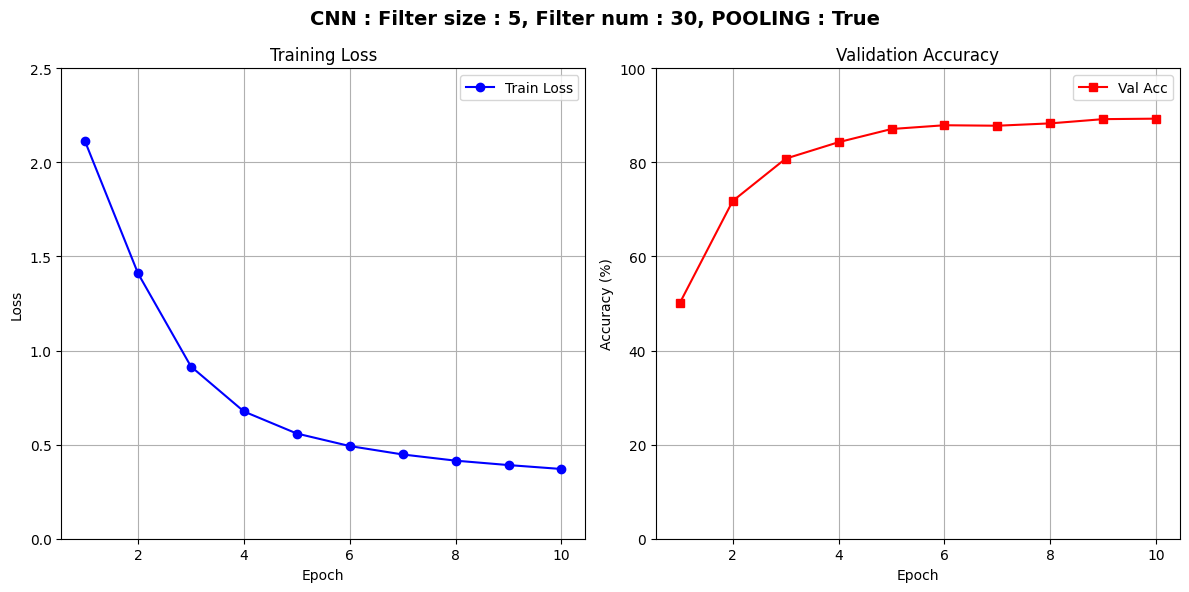

In [13]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.suptitle(f"CNN : Filter size : {FILTER_SIZE}, Filter num : {FILTER_NUM}, POOLING : {MAX_POOL}",
             fontsize=14, fontweight='bold', y=0.98)


# --- 왼쪽: Training Loss (스케일 0 ~ 2.5 고정!) ---
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='blue', label='Train Loss')
plt.title(f'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 2.5)
plt.grid(True)
plt.legend()

# --- 오른쪽: Validation Accuracy (스케일 0 ~ 100 고정) ---
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), val_accuracies, marker='s', color='red', label='Val Acc')
plt.title(f'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()